# Exploratory Data Analysis (EDA) for HDB Resale Prices Dataset

This notebook performs Exploratory Data Analysis (EDA) on the HDB resale dataset.
The goal is to understand the structure of the data, check for issues, and prepare
it for the cleaning and transformation steps in our ETL pipeline.

We focus on:
* Loading the raw CSV file
* Checking the shape of the dataset (rows and columns)
* Looking for missing values or incorrect data
* Understanding each column and the data types
* Basic summaries and visual checks


### 1. Load the CSV file

We read the raw resale_flat_prices CSV that was downloaded from the API in Notebook 00.

Pandas converts the CSV into a DataFrame, which lets us inspect and analyze the data easily.

In [1]:
import pandas as pd # Loads panda for tables and data wrangling
import numpy as np # Loads numpy for numeric processing
import matplotlib.pyplot as plt # Loads pyplot for creating plots and visualizations
import seaborn as sns # Loads seaborn for creating informative statistical graphics 
import os # Loads os for file system operations

pd.set_option("display.max_columns", None) # To show all columns when printing the dataframe
raw_path = "../data/raw/resale_flat_prices_2017_onwards.csv" # stores the relative location of the CSV file
print(os.path.exists(raw_path))  # To check if that path is valid and prints True or False (Expected it to be True)
df = pd.read_csv(raw_path) # Loads the CSV into a pandas dataframe named df
df.head() # Shows the first 5 rows for a quick preview

True


,_id,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,1,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,3,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,4,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,5,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


#### 2. Dataset Overview
What this section does:
* Shows df.info()
* Displays full descriptive statistics (df.describe())
* Measures missing values
* Checks for duplicate rows

This identifies potential data quality issues early, ensuring the ETL pipeline can be designed to clean and handle imperfect data.

Key Findings:
* Over 220k rows and 12 original columns
* No missing values
* No duplicate rows
* Column types include strings, numbers, and dates

##### Checking for Missing or Dirty Data

We check .describe() for numeric columns to ensure values look reasonable.

df.isna().sum() counts how many missing values exist in each column.
This helps us spot columns that may need cleaning or special handling.

In [2]:
df.info() # Provides a concise summary of the DataFrame eg 220 174 rows 12 columns non null
df.describe() # Provides summary statistics for numeric columns eg count, mean, std

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220289 entries, 0 to 220288
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   _id                  220289 non-null  int64  
 1   month                220289 non-null  object 
 2   town                 220289 non-null  object 
 3   flat_type            220289 non-null  object 
 4   block                220289 non-null  object 
 5   street_name          220289 non-null  object 
 6   storey_range         220289 non-null  object 
 7   floor_area_sqm       220289 non-null  float64
 8   flat_model           220289 non-null  object 
 9   lease_commence_date  220289 non-null  int64  
 10  remaining_lease      220289 non-null  object 
 11  resale_price         220289 non-null  float64
dtypes: float64(2), int64(2), object(8)
memory usage: 20.2+ MB


,_id,floor_area_sqm,lease_commence_date,resale_price
count,220289.000000,220289.000000,220289.000000,2.202890e+05
mean,110145.000000,96.779375,1996.422041,5.233744e+05
std,63592.101062,24.022016,14.294791,1.859712e+05
min,1.000000,31.000000,1966.000000,1.400000e+05
25%,55073.000000,81.000000,1985.000000,3.850000e+05
50%,110145.000000,93.000000,1997.000000,4.900000e+05
75%,165217.000000,112.000000,2012.000000,6.288880e+05
max,220289.000000,366.700000,2022.000000,1.658888e+06


In [3]:
df.isnull().sum().sort_values(ascending=False)
# Check every column and count how many empty or missing values it has.
# Then list the columns starting with the one that has the most missing values.

_id                    0
month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

##### Inspect Text Columns

We check the unique values for columns like 'town', 'flat_type', and 'flat_model'.
This helps us confirm that category names look correct and do not contain mistakes.

In [4]:
for col in ['town', 'flat_type', 'flat_model']:
    print(f"{col}:", df[col].nunique(), "unique values")
    print(df[col].unique())
    print()

town: 26 unique values
['ANG MO KIO' 'BEDOK' 'BISHAN' 'BUKIT BATOK' 'BUKIT MERAH' 'BUKIT PANJANG'
 'BUKIT TIMAH' 'CENTRAL AREA' 'CHOA CHU KANG' 'CLEMENTI' 'GEYLANG'
 'HOUGANG' 'JURONG EAST' 'JURONG WEST' 'KALLANG/WHAMPOA' 'MARINE PARADE'
 'PASIR RIS' 'PUNGGOL' 'QUEENSTOWN' 'SEMBAWANG' 'SENGKANG' 'SERANGOON'
 'TAMPINES' 'TOA PAYOH' 'WOODLANDS' 'YISHUN']

flat_type: 7 unique values
['2 ROOM' '3 ROOM' '4 ROOM' '5 ROOM' 'EXECUTIVE' '1 ROOM'
 'MULTI-GENERATION']

flat_model: 21 unique values
['Improved' 'New Generation' 'DBSS' 'Standard' 'Apartment' 'Simplified'
 'Model A' 'Premium Apartment' 'Adjoined flat' 'Model A-Maisonette'
 'Maisonette' 'Type S1' 'Type S2' 'Model A2' 'Terrace'
 'Improved-Maisonette' 'Premium Maisonette' 'Multi Generation'
 'Premium Apartment Loft' '2-room' '3Gen']



##### Duplicate Check
This checks how many rows in the dataset are exact duplicates across every column.
If two rows are completely identical, they would be counted here.
A result of 0 means there are no full-row duplicates, so every row is unique.

Counting the total number of duplicate rows in a DataFrame df, sum() method counts the number of True values, whereby True is 1 (means there is duplicate) and False is 0 (means there is no duplicate). 

In the below snapshot there are no exact duplicate rows based on all columns. We will still keep deduplication logic in ETL in case future datasets introduce duplicates.

In [5]:
df.duplicated().sum() 
# Count how many rows are exact duplicates across ALL columns
# To check for Data entry duplication so to avoid double counting. 
# Result: 0, so no full-row duplicates in this dataset.

np.int64(0)

#### 3. Data Cleaning Preview

In this step, we do light cleaning to make the data easier to use later.
This includes:

* Converting text-based numbers into real numeric types
* Making sure date columns are in proper datetime format
* Removing or fixing any obviously wrong values
* Cleaning up formatting issues if needed

We keep this part simple because full cleaning will happen later during the Transform Phase.

##### Why we convert the month column to a datetime

The month column originally comes in as text (example: "2017-01").
To use it for analytics, sorting, grouping, or SQL operations, we must convert it to a real datetime.

Extracting Year, Month, and Year-Month helps EDA by making it easier to group, sort, filter, and visualize trends over time. These fields also help prepare the data for SQL queries and dashboards in later stages of the project.

In [6]:
df["month"] = pd.to_datetime(df["month"], format="%Y-%m") # Converts the month column from a text eg 2017-01 to a real datetime value eg 2017-01-01
df["year"] = df["month"].dt.year # Extracts just the numeric year eg 2017
df["month_num"] = df["month"].dt.month # Extracts month number 1 to 12
df["year_month"] = df["month"].dt.to_period("M") # Converts to a "Period" type such as 2017-01 for grouping by month

In [7]:
df.head() # Shows the first 5 rows

,_id,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,year,month_num,year_month
0,1,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,2017,1,2017-01
1,2,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,2017,1,2017-01
2,3,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,2017,1,2017-01
3,4,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,2017,1,2017-01
4,5,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,2017,1,2017-01


In [8]:
df.info() # Shows the updated structure after transformation eg 15 columns instead of 12 and new columns are of correct data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220289 entries, 0 to 220288
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   _id                  220289 non-null  int64         
 1   month                220289 non-null  datetime64[ns]
 2   town                 220289 non-null  object        
 3   flat_type            220289 non-null  object        
 4   block                220289 non-null  object        
 5   street_name          220289 non-null  object        
 6   storey_range         220289 non-null  object        
 7   floor_area_sqm       220289 non-null  float64       
 8   flat_model           220289 non-null  object        
 9   lease_commence_date  220289 non-null  int64         
 10  remaining_lease      220289 non-null  object        
 11  resale_price         220289 non-null  float64       
 12  year                 220289 non-null  int32         
 13  month_num     

#### 4. Categorical Feature Exploration
What this section does:

Examines the distribution of key categorical fields:
* Town
* Flat type
* Flat model
* Storey range

Helps uncover:
* Standardization issues
* Rare categories
* Fields suitable for dimension tables in SQL
* Patterns that might influence ETL transformations

Key Observations:
* Most common towns: Sengkang, Punggol, Woodlands
* Most common flat types: 4-Room, 5-Room, 3-Room
* Flat models like Model A, Improved, New Generation dominate the dataset
* No unexpected categories found

In [9]:
df["town"].value_counts().head(10) # Gives the frequency of each category and to detect any anomaly

town
SENGKANG         18020
PUNGGOL          16039
WOODLANDS        15614
YISHUN           15032
TAMPINES         15012
JURONG WEST      14544
BEDOK            11448
HOUGANG          11138
CHOA CHU KANG     9954
BUKIT BATOK       9135
Name: count, dtype: int64

In [10]:
df["flat_type"].value_counts() # Gives the frequency of each category and to detect any anomaly

flat_type
4 ROOM              93347
5 ROOM              54048
3 ROOM              52450
EXECUTIVE           15839
2 ROOM               4441
MULTI-GENERATION       84
1 ROOM                 80
Name: count, dtype: int64

In [11]:
df["flat_model"].value_counts().head(10) # Gives the frequency of each category and to detect any anomaly

flat_model
Model A              78670
Improved             53797
New Generation       27025
Premium Apartment    24331
Simplified            8439
Apartment             7928
Maisonette            6075
Standard              5914
DBSS                  3537
Model A2              2489
Name: count, dtype: int64

#### 5. Visual Explorations (EDA Visuals)
What this section does:

We use simple charts to understand the data better. Visuals make patterns easier to see than tables alone. 

The charts here help us explore:
* How resale prices are distributed
* How many transactions happen each year
* How prices differ across flat types
* How prices change over time
* Which towns have the most resale activity

These insights help shape the SQL transformations and dashboards later in the ETL project.

Key Insights from the Visuals:

* Resale prices are right-skewed, with most flats priced between 300k–700k and some going above 1.6M.
* 2021 had the highest number of transactions, likely due to post-pandemic market movements.
* Prices increased sharply after 2020, showing a strong upward trend.
* Larger flats (5-Room, Executive, Multi-Generation) have much higher average prices than 3-Room or 4-Room units.
* Most common resale towns include Sengkang, Punggol, Woodlands, Yishun, and Tampines.

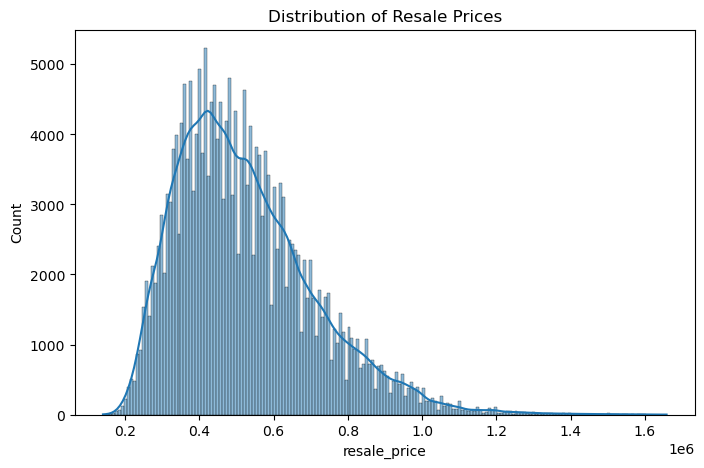

In [12]:
# Distribution of resale prices. It helps identify skewness, outliers, price ranges.

plt.figure(figsize=(8,5))
sns.histplot(df["resale_price"], kde=True)
plt.title("Distribution of Resale Prices")
plt.show()

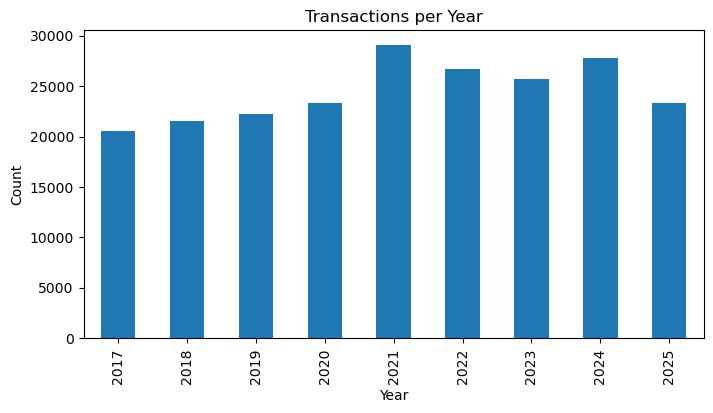

In [13]:
# Number of transactions by year. It shows transaction volume and market activity.

df.groupby("year").size().plot(kind="bar", figsize=(8,4))
plt.title("Transactions per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

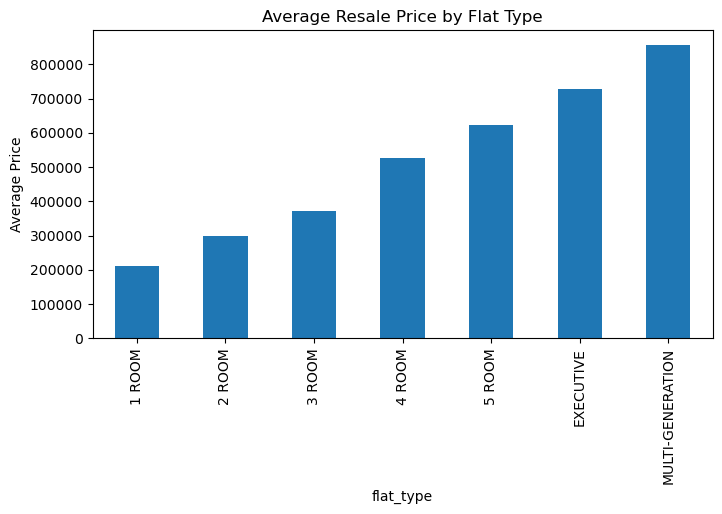

In [14]:
# Average resale price by flat type. It shows pricing differences based on unit size.

df.groupby("flat_type")["resale_price"].mean().sort_values().plot(
    kind="bar", figsize=(8,4)
)
plt.title("Average Resale Price by Flat Type")
plt.ylabel("Average Price")
plt.show()

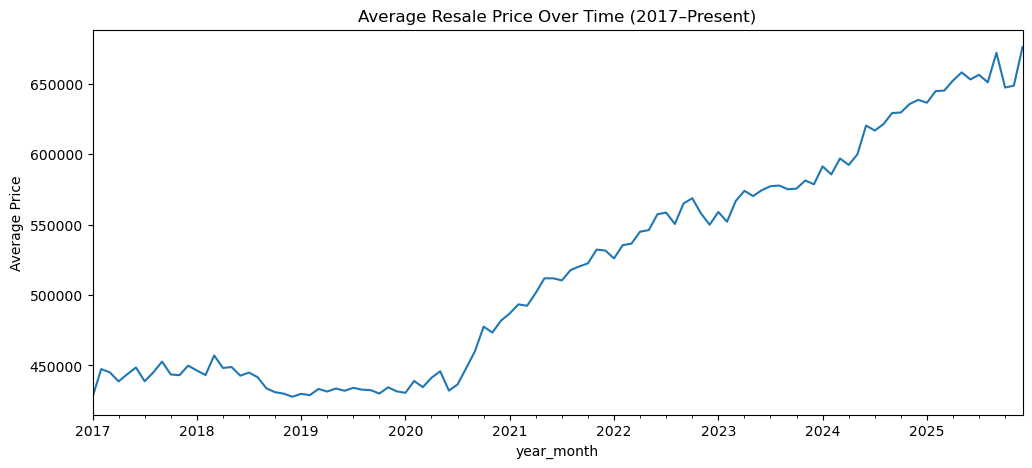

In [15]:
# Trendline: Price over time (for all flats). It tells us how the market changed over time.

monthly_avg = df.groupby("year_month")["resale_price"].mean()

plt.figure(figsize=(12,5))
monthly_avg.plot()
plt.title("Average Resale Price Over Time (2017–Present)")
plt.ylabel("Average Price")
plt.show()

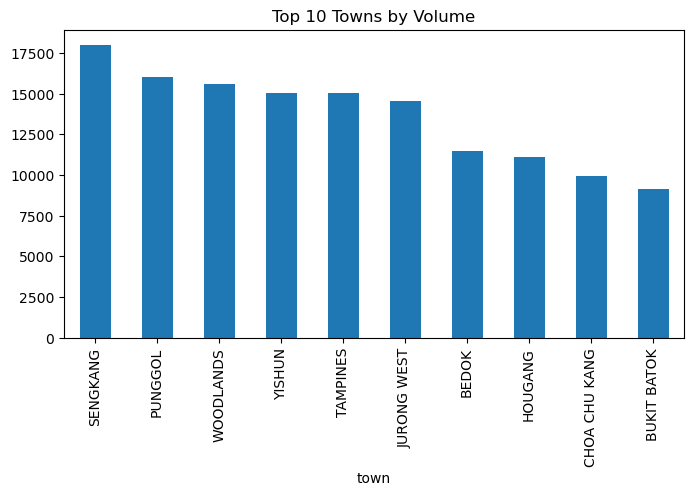

In [16]:
# Top 10 most common towns in dataset. It shows “hot areas” and helps in town-level analytics. 

df["town"].value_counts().head(10).plot(kind="bar", figsize=(8,4))
plt.title("Top 10 Towns by Volume")
plt.show()

# Summary of Findings

#### Data Quality

* No missing values in the dataset, so cleaning is minimal.
* The month column must be converted to datetime.
* The remaining_lease column is written in different ways, like ‘92 years’ or ‘92 years 03 months’.
  We will need to tidy it up so every value follows the same format.
* Categorical fields look consistent and clean.

#### Dataset Characteristics

* Over 220K resale records from 2017 to present.
* Most common towns: Sengkang, Punggol, Woodlands, Yishun, Tampines.
* Resale prices range from about 140k to over 1.6M.
* Prices rose sharply after 2020.

#### Why This Matters for ETL

* Duplicates must be removed before loading.
* Date fields should be standardized for time-series analysis.
* Categorical fields are stable for direct loading.
* Numeric fields are clean and ready for PostgreSQL storage.

This EDA confirms that the dataset is well-structured and suitable for transformation and loading.